<a href="https://colab.research.google.com/github/AngelaOrtiz25/aprendizaje_maquina/blob/Redes_Neuronales_Recurrentes_SimpleRNN/Redes_Neuronales_Recurrentes__SimpleRNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Redes Neuronales Recurrentes: SimpleRNN**

# Capa Recurrente:
- Procesa los elementos de la secuencia uno por uno.
- Mantiene un estado interno (a menudo llamado "memoria" o "hidden state") que se actualiza en cada paso.
- En cada nuevo paso, la salida y el estado interno se calculan en función de: $1)$ la entrada actual y $2)$ el estado interno anterior.

## ¿Qué es una SimpleRNN?

Una **Red Neuronal Recurrente Simple (SimpleRNN)** es un tipo de red neuronal diseñada para procesar secuencias de datos manteniendo un estado interno que actúa como memoria.

## Aplicaciones Principales
Las capas recurrentes son ideales para tareas donde la entrada y/o la salida son secuencias:

- **Procesamiento de Lenguaje Natural (NLP):** Traducción automática, generación de texto, análisis de sentimientos, corrección ortográfica.
- **Reconocimiento de Voz:** Transcribir audio a texto.
- **Análisis de Series de Tiempo:** Predecir el precio de una acción, la demanda de energía o el clima.
- **Subtitulado de Videos:** Generar una descripción para cada frame de un video.


## Desventajas y las Mejoras: LSTM y GRU
La RNN simple tiene un gran problema: el "problema del gradiente vanishing/exploding". Básicamente, cuando la secuencia es muy larga, la red tiene dificultades para aprender dependencias a largo plazo. La "memoria" se va desvaneciendo o se desborda.

Para solucionarlo, se desarrollaron arquitecturas más complejas y eficaces:

- LSTM (Long Short-Term Memory): Introduce un mecanismo de "puertas" (de entrada, olvido y salida) que le permite aprender qué información recordar y qué información descartar de forma selectiva. Es excelente para capturar dependencias de largo plazo.

- GRU (Gated Recurrent Unit): Es una versión simplificada de la LSTM, con menos puertas, que a menudo logra un rendimiento similar pero es más rápida de entrenar.

**Gradiente vanishing:** La señal de aprendizaje se vuelve tan débil después de muchos pasos que las capas iniciales de la secuencia prácticamente dejan de aprender.Gradiente vanishing = La señal de aprendizaje se vuelve tan débil después de muchos pasos que las capas iniciales de la secuencia prácticamente dejan de aprender.

# `tf.keras.layers.SimpleRNN`

```python
tf.keras.layers.SimpleRNN(
    units,
    activation='tanh',
    use_bias=True,
    kernel_initializer='glorot_uniform',
    recurrent_initializer='orthogonal',
    bias_initializer='zeros',
    kernel_regularizer=None,
    recurrent_regularizer=None,
    bias_regularizer=None,
    activity_regularizer=None,
    kernel_constraint=None,
    recurrent_constraint=None,
    bias_constraint=None,
    dropout=0.0,
    recurrent_dropout=0.0,
    return_sequences=False,
    return_state=False,
    go_backwards=False,
    stateful=False,
    unroll=False,
    seed=None,
    **kwargs
)
```
https://www.tensorflow.org/api_docs/python/tf/keras/layers/SimpleRNN

## Ecuación de una SimpleRNN
La ecuación fundamental de una RNN
$$h_t = f(W_x \cdot x_t + W_h \cdot h_{t-1} + b)$$
Donde
- $h_t$: Estado oculto en el tiempo $t$
- $x_t$: Entrada en el tiempo $t$
- $W_x$: Matriz de pesos de entrada
- $W_h$: Matriz de pesos recurrentes
- $b$: Vector de sesgo
- $f()$: Función de activación

Para cada paso de tiempo $t$, la SimpleRNN calcula:

$$
h_t = \tanh(W_x \cdot x_t + W_h \cdot h_{t-1} + b)
$$

- $\tanh$: Función de activación
- tanh, sigmoid, ReLU


# Mini-Ejemplo Numérico Paso a Paso

## Configuración del Ejemplo

Definimos los parámetros de nuestra SimpleRNN:

- **Unidades**: 2 neuronas
- **Secuencia de entrada**: 3 pasos de tiempo
- **Features por paso**: 2

## Paso 1: Definición de Parámetros

### Pesos y Sesgos

$$
W_x = \begin{bmatrix}
0.5 & 0.2 \\
0.3 & 0.8
\end{bmatrix}, \quad
W_h = \begin{bmatrix}
0.1 & 0.4 \\
0.6 & 0.9
\end{bmatrix}, \quad
b = \begin{bmatrix}
0.1 & 0.2
\end{bmatrix}
$$

### Secuencia de Entrada

$$
X = \begin{bmatrix}
0.8 & 0.2 \\
0.5 & 0.7 \\
0.3 & 0.9
\end{bmatrix}
$$

### Estado Inicial

$$
h_0 = \begin{bmatrix}
0.0 & 0.0
\end{bmatrix}
$$

## Paso 2: Cálculo para t = 1

### Entrada del primer paso:

$$
x_1 = \begin{bmatrix} 0.8 & 0.2 \end{bmatrix}
$$

### Cálculo del nuevo estado:

$$
h_1 = \tanh(x_1 \cdot W_x^T + h_0 \cdot W_h^T + b)
$$

$$
h_1 = \tanh\left(
\begin{bmatrix} 0.8 & 0.2 \end{bmatrix} \cdot
\begin{bmatrix} 0.5 & 0.3 \\ 0.2 & 0.8 \end{bmatrix} +
\begin{bmatrix} 0.0 & 0.0 \end{bmatrix} \cdot
\begin{bmatrix} 0.1 & 0.6 \\ 0.4 & 0.9 \end{bmatrix} +
\begin{bmatrix} 0.1 & 0.2 \end{bmatrix}
\right)
$$

$$
h_1 = \tanh\left(
\begin{bmatrix} 0.8 \times 0.5 + 0.2 \times 0.2 & 0.8 \times 0.3 + 0.2 \times 0.8 \end{bmatrix} +
\begin{bmatrix} 0.0 & 0.0 \end{bmatrix} +
\begin{bmatrix} 0.1 & 0.2 \end{bmatrix}
\right)
$$

$$
h_1 = \tanh\left(
\begin{bmatrix} 0.4 + 0.04 & 0.24 + 0.16 \end{bmatrix} +
\begin{bmatrix} 0.1 & 0.2 \end{bmatrix}
\right)
$$

$$
h_1 = \tanh\left(
\begin{bmatrix} 0.44 & 0.40 \end{bmatrix} +
\begin{bmatrix} 0.1 & 0.2 \end{bmatrix}
\right)
$$

$$
h_1 = \tanh\left(
\begin{bmatrix} 0.54 & 0.60 \end{bmatrix}
\right)
$$

$$
h_1 = \begin{bmatrix} \tanh(0.54) & \tanh(0.60) \end{bmatrix} =
\begin{bmatrix} 0.49 & 0.54 \end{bmatrix}
$$

## Paso 3: Cálculo para t = 2

\textbf{Entrada en $t=2$}:
$$
x_2 = \begin{bmatrix} 0.5 & 0.7 \end{bmatrix}
$$

\textbf{Cálculo del nuevo estado}:
\begin{align*}
h_2 &= \tanh(x_2 \cdot W_x^T + h_1 \cdot W_h^T + b) \\
&= \tanh\left(
\begin{bmatrix} 0.5 & 0.7 \end{bmatrix} \cdot
\begin{bmatrix} 0.5 & 0.3 \\ 0.2 & 0.8 \end{bmatrix} +
\begin{bmatrix} 0.49 & 0.54 \end{bmatrix} \cdot
\begin{bmatrix} 0.1 & 0.6 \\ 0.4 & 0.9 \end{bmatrix} +
\begin{bmatrix} 0.1 & 0.2 \end{bmatrix}
\right) \\
&= \tanh\left(
\begin{bmatrix} (0.5 \times 0.5 + 0.7 \times 0.2) & (0.5 \times 0.3 + 0.7 \times 0.8) \end{bmatrix} +
\begin{bmatrix} (0.49 \times 0.1 + 0.54 \times 0.4) & (0.49 \times 0.6 + 0.54 \times 0.9) \end{bmatrix} +
\begin{bmatrix} 0.1 & 0.2 \end{bmatrix}
\right) \\
&= \tanh\left(
\begin{bmatrix} (0.25 + 0.14) & (0.15 + 0.56) \end{bmatrix} +
\begin{bmatrix} (0.049 + 0.216) & (0.294 + 0.486) \end{bmatrix} +
\begin{bmatrix} 0.1 & 0.2 \end{bmatrix}
\right) \\
&= \tanh\left(
\begin{bmatrix} 0.39 & 0.71 \end{bmatrix} +
\begin{bmatrix} 0.265 & 0.780 \end{bmatrix} +
\begin{bmatrix} 0.1 & 0.2 \end{bmatrix}
\right) \\
&= \tanh\left(
\begin{bmatrix} 0.39 + 0.265 + 0.1 & 0.71 + 0.780 + 0.2 \end{bmatrix}
\right) \\
&= \tanh\left(
\begin{bmatrix} 0.755 & 1.690 \end{bmatrix}
\right) \\
&= \begin{bmatrix} \tanh(0.755) & \tanh(1.690) \end{bmatrix} \\
&= \begin{bmatrix} 0.64 & 0.93 \end{bmatrix}
\end{align*}

## Paso 4: Cálculo para $t = 3$
$$
x_3 = \begin{bmatrix} 0.3 & 0.9 \end{bmatrix}
$$

\textbf{Cálculo del nuevo estado}:
\begin{align*}
h_3 &= \tanh(x_3 \cdot W_x^T + h_2 \cdot W_h^T + b) \\
&= \tanh\left(
\begin{bmatrix} 0.3 & 0.9 \end{bmatrix} \cdot
\begin{bmatrix} 0.5 & 0.3 \\ 0.2 & 0.8 \end{bmatrix} +
\begin{bmatrix} 0.64 & 0.93 \end{bmatrix} \cdot
\begin{bmatrix} 0.1 & 0.6 \\ 0.4 & 0.9 \end{bmatrix} +
\begin{bmatrix} 0.1 & 0.2 \end{bmatrix}
\right) \\
&= \tanh\left(
\begin{bmatrix} (0.3 \times 0.5 + 0.9 \times 0.2) & (0.3 \times 0.3 + 0.9 \times 0.8) \end{bmatrix} +
\begin{bmatrix} (0.64 \times 0.1 + 0.93 \times 0.4) & (0.64 \times 0.6 + 0.93 \times 0.9) \end{bmatrix} +
\begin{bmatrix} 0.1 & 0.2 \end{bmatrix}
\right) \\
&= \tanh\left(
\begin{bmatrix} (0.15 + 0.18) & (0.09 + 0.72) \end{bmatrix} +
\begin{bmatrix} (0.064 + 0.372) & (0.384 + 0.837) \end{bmatrix} +
\begin{bmatrix} 0.1 & 0.2 \end{bmatrix}
\right) \\
&= \tanh\left(
\begin{bmatrix} 0.33 & 0.81 \end{bmatrix} +
\begin{bmatrix} 0.436 & 1.221 \end{bmatrix} +
\begin{bmatrix} 0.1 & 0.2 \end{bmatrix}
\right) \\
&= \tanh\left(
\begin{bmatrix} 0.33 + 0.436 + 0.1 & 0.81 + 1.221 + 0.2 \end{bmatrix}
\right) \\
&= \tanh\left(
\begin{bmatrix} 0.866 & 2.231 \end{bmatrix}
\right) \\
&= \begin{bmatrix} \tanh(0.866) & \tanh(2.231) \end{bmatrix} \\
&= \begin{bmatrix} 0.70 & 0.98 \end{bmatrix}
\end{align*}

#Resultado Final

Los estados ocultos calculados son:
* $h_1 = \begin{bmatrix} 0.49 & 0.54 \end{bmatrix}$
* $h_2 = \begin{bmatrix} 0.64 & 0.93 \end{bmatrix}$
* $h_3 = \begin{bmatrix} 0.70 & 0.98 \end{bmatrix}$


El \textbf{estado final} $h_3 = \begin{bmatrix} 0.70 & 0.98 \end{bmatrix}$ representa la memoria de la red después de procesar toda la secuencia de entrada.

return_sequences=False (usa solo h₃).
a apilar múltiples capas RNN una después de la otra, formando una red neuronal recurrente profunda. La salida de la primera capa RNN se convierte en la entrada de la segunda capa RNN, se usa return_sequences=True (usa h₁, h₂, h₃).


## SimpleRNN con un ejemplo práctico de drones y datos climáticos

1. GENERAR DATOS SIMULADOS PARA DRONES Y CLIMA


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd


1. GENERANDO DATOS BALANCEADOS (CORREGIDO)
Forma de X: (2000, 10, 5)
Forma de y: (2000, 3)

Distribución de clases en entrenamiento:
Volar: 524.0 (32.8%)
Alerta: 553.0 (34.6%)
Cancelar: 523.0 (32.7%)

 DISTRIBUCIÓN BALANCEADA:
  Volar: 666 muestras (33.3%)
  Alerta: 666 muestras (33.3%)
  Cancelar: 668 muestras (33.4%)

HISTOGRAMAS DE LAS CARACTERÍSTICAS CLIMÁTICAS


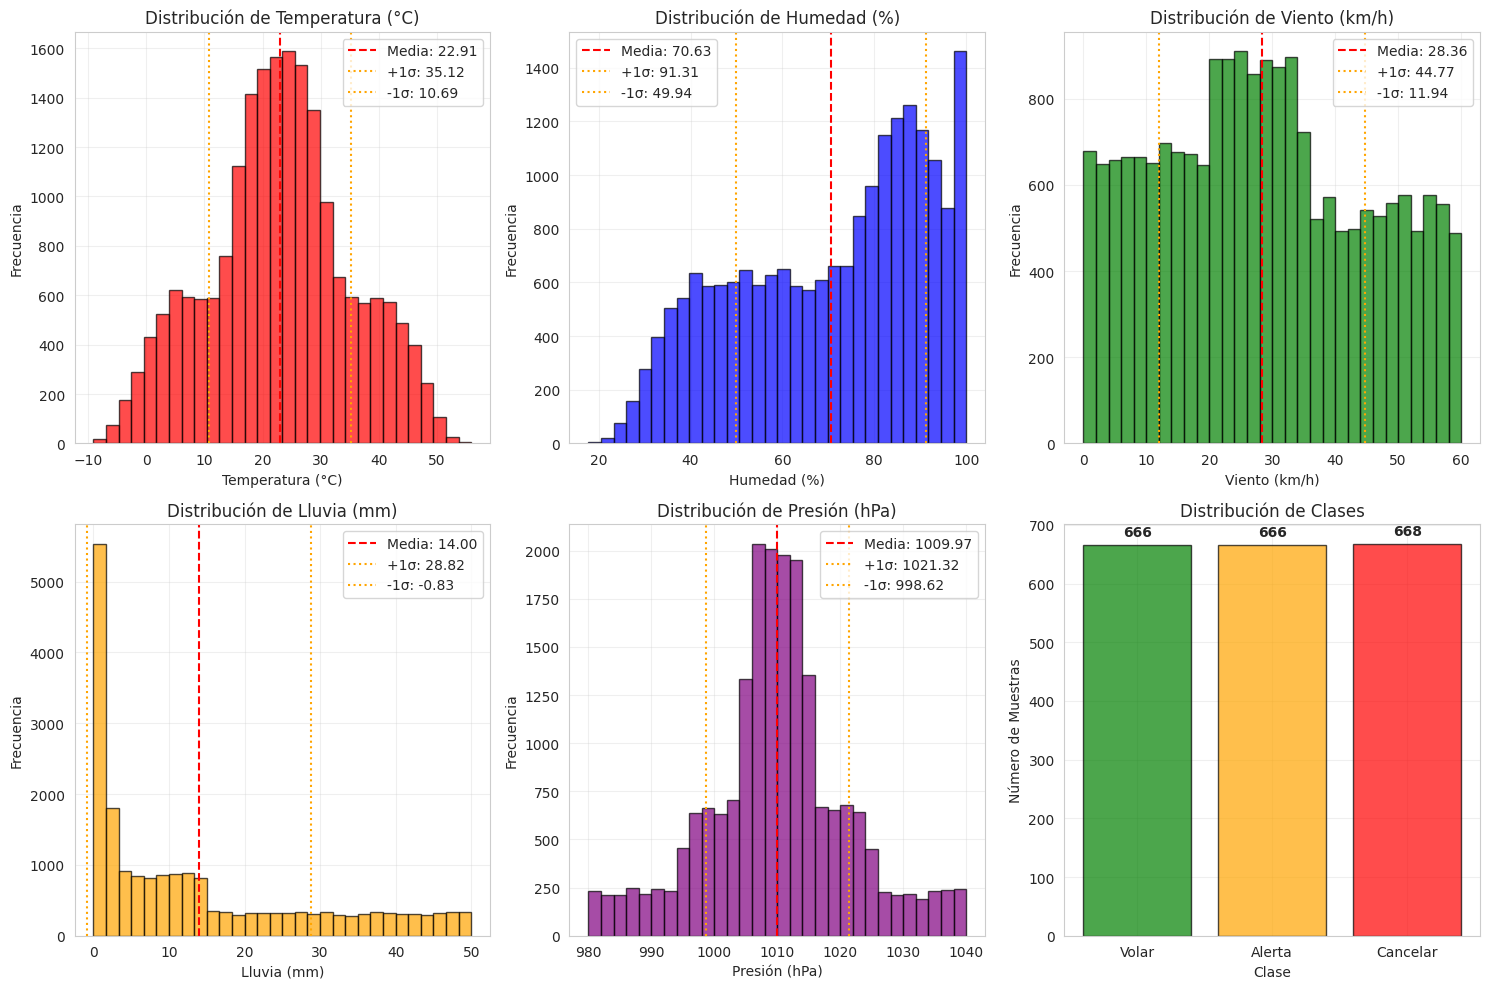


ESTADÍSTICAS DESCRIPTIVAS POR CLASE:

--- Volar ---
Temperatura: Media=22.93, Std=4.74, Min=10.48, Max=35.47
Humedad: Media=45.76, Std=9.99, Min=17.77, Max=75.17
Viento: Media=10.02, Std=5.77, Min=0.00, Max=20.00
Lluvia: Media=1.01, Std=0.58, Min=0.00, Max=2.00
Presión: Media=1009.98, Std=2.90, Min=1005.00, Max=1015.00

--- Alerta ---
Temperatura: Media=23.05, Std=13.13, Min=-4.26, Max=50.18
Humedad: Media=75.72, Std=10.07, Min=47.99, Max=100.00
Viento: Media=27.49, Std=4.34, Min=20.00, Max=35.00
Lluvia: Media=8.47, Std=3.75, Min=2.00, Max=15.00
Presión: Media=1009.97, Std=8.56, Min=995.01, Max=1024.99

--- Cancelar ---
Temperatura: Media=22.74, Std=15.88, Min=-9.11, Max=55.88
Humedad: Media=90.34, Std=7.02, Min=66.72, Max=100.00
Viento: Media=47.51, Std=7.19, Min=35.00, Max=60.00
Lluvia: Media=32.46, Std=10.19, Min=15.01, Max=50.00
Presión: Media=1009.96, Std=17.44, Min=980.00, Max=1039.99


In [ ]:
# Configuración
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style("whitegrid")

print("\n" + "="*60)
print("1. GENERANDO DATOS BALANCEADOS (CORREGIDO)")
print("="*60)

# PRIMERO DEFINIR LAS VARIABLES (esto te faltaba)
n_muestras = 2000
n_timesteps = 10
n_features = 5

def generar_datos_balanceados(n_muestras, n_timesteps, n_features):
    np.random.seed(1234)
    X = np.zeros((n_muestras, n_timesteps, n_features))  #
    y = np.zeros((n_muestras, 3)) #matriz de etiquetas de 3 clases [1, 0, 0] → Volar [0, 1, 0] → Alerta [0, 0, 1] → Cancelar

    # Distribución balanceada: 33% cada clase
    n_por_clase = n_muestras // 3

    for i in range(n_muestras):
        # Determinar qué clase generar (balanceado)
        if i < n_por_clase:
            clase_objetivo = 0  # VOLAR
        elif i < 2 * n_por_clase:
            clase_objetivo = 1  # ALERTA
        else:
            clase_objetivo = 2  # CANCELAR

        # Generar clima según la clase objetivo
        if clase_objetivo == 0:  # CONDICIONES ÓPTIMAS (VOLAR)
            temp = np.random.uniform(15, 30, n_timesteps)      # 15-30°C
            humedad = np.random.uniform(30, 60, n_timesteps)   # 30-60%
            viento = np.random.uniform(0, 20, n_timesteps)     # 0-20 km/h
            lluvia = np.random.uniform(0, 2, n_timesteps)      # 0-2 mm
            presion = np.random.uniform(1005, 1015, n_timesteps)
            y[i] = [1, 0, 0]

        elif clase_objetivo == 1:  # CONDICIONES PELIGROSAS (ALERTA)
            temp = np.random.uniform(0, 45, n_timesteps)       # Rango amplio
            humedad = np.random.uniform(60, 90, n_timesteps)   # 60-90%
            viento = np.random.uniform(20, 35, n_timesteps)    # 20-35 km/h
            lluvia = np.random.uniform(2, 15, n_timesteps)     # 2-15 mm
            presion = np.random.uniform(995, 1025, n_timesteps)
            y[i] = [0, 1, 0]

        else:  # CONDICIONES EXTREMAS (CANCELAR)
            temp = np.random.uniform(-5, 50, n_timesteps)      # Extremos
            humedad = np.random.uniform(80, 100, n_timesteps)  # 80-100%
            viento = np.random.uniform(35, 60, n_timesteps)    # 35-60 km/h
            lluvia = np.random.uniform(15, 50, n_timesteps)    # 15-50 mm
            presion = np.random.uniform(980, 1040, n_timesteps)
            y[i] = [0, 0, 1]

        # Añadir algo de ruido y patrones realistas
        estacionalidad = np.sin(2 * np.pi * np.arange(n_timesteps) / 365)
        temp += 5 * estacionalidad + np.random.normal(0, 2, n_timesteps)
        humedad += 10 * estacionalidad + np.random.normal(0, 5, n_timesteps)

        # Asignar a X
        X[i, :, 0] = temp
        X[i, :, 1] = np.clip(humedad, 0, 100)
        X[i, :, 2] = np.clip(viento, 0, 60)
        X[i, :, 3] = np.clip(lluvia, 0, 50)
        X[i, :, 4] = presion

    return X, y

# SOLO usar la nueva función balanceada - → X es un tensor con 2000 muestras, cada una de 10 pasos de tiempo × 5 variables.→ y son 2000 etiquetas one-hot con 3 clases.
X, y = generar_datos_balanceados(n_muestras, n_timesteps, n_features)
print(f"Forma de X: {X.shape}")  # (muestras, timesteps, features)
print(f"Forma de y: {y.shape}")  # (muestras, 3 clases)

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #80% datos para entrenar, 20% para prueba, 42 semilla

print(f"\nDistribución de clases en entrenamiento:")
print(f"Volar: {np.sum(y_train[:, 0])} ({np.sum(y_train[:, 0])/len(y_train):.1%})")
print(f"Alerta: {np.sum(y_train[:, 1])} ({np.sum(y_train[:, 1])/len(y_train):.1%})")
print(f"Cancelar: {np.sum(y_train[:, 2])} ({np.sum(y_train[:, 2])/len(y_train):.1%})")

# Verificar distribución de clases
print(f"\n DISTRIBUCIÓN BALANCEADA:")
y_classes = np.argmax(y, axis=1)
clases, conteos = np.unique(y_classes, return_counts=True)
nombres_clases = ['Volar', 'Alerta', 'Cancelar']

for clase, conteo, nombre in zip(clases, conteos, nombres_clases):
    porcentaje = (conteo / len(y)) * 100
    print(f"  {nombre}: {conteo} muestras ({porcentaje:.1f}%)")

###################################
#  HISTOGRAMAS DE LOS DATOS
###################################
print("\n" + "="*60)
print("HISTOGRAMAS DE LAS CARACTERÍSTICAS CLIMÁTICAS")
print("="*60)

# Crear figura para histogramas
plt.figure(figsize=(15, 10))

# Aplanar los datos para los histogramas (todas las muestras y todos los timesteps)
caracteristicas = ['Temperatura (°C)', 'Humedad (%)', 'Viento (km/h)', 'Lluvia (mm)', 'Presión (hPa)']
colores = ['red', 'blue', 'green', 'orange', 'purple']

for i in range(n_features):
    plt.subplot(2, 3, i+1)
    # Tomar todos los valores de la característica i
    datos = X[:, :, i].flatten()
    plt.hist(datos, bins=30, alpha=0.7, color=colores[i], edgecolor='black')
    plt.title(f'Distribución de {caracteristicas[i]}')
    plt.xlabel(caracteristicas[i])
    plt.ylabel('Frecuencia')
    plt.grid(True, alpha=0.3)

    # Agregar estadísticas descriptivas
    mean_val = np.mean(datos)
    std_val = np.std(datos)
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Media: {mean_val:.2f}')
    plt.axvline(mean_val + std_val, color='orange', linestyle=':', label=f'+1σ: {mean_val+std_val:.2f}')
    plt.axvline(mean_val - std_val, color='orange', linestyle=':', label=f'-1σ: {mean_val-std_val:.2f}')
    plt.legend()

# Histograma de distribución de clases
plt.subplot(2, 3, 6)
y_classes = np.argmax(y, axis=1)
clases, conteos = np.unique(y_classes, return_counts=True)
nombres_clases = ['Volar', 'Alerta', 'Cancelar']
colores_clases = ['green', 'orange', 'red']

plt.bar(nombres_clases, conteos, color=colores_clases, alpha=0.7, edgecolor='black')
plt.title('Distribución de Clases')
plt.xlabel('Clase')
plt.ylabel('Número de Muestras')

# Agregar valores encima de las barras
for i, conteo in enumerate(conteos):
    plt.text(i, conteo + 10, str(conteo), ha='center', va='bottom', fontweight='bold')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar estadísticas descriptivas por clase
print(f"\nESTADÍSTICAS DESCRIPTIVAS POR CLASE:")
nombres_caracteristicas = ['Temperatura', 'Humedad', 'Viento', 'Lluvia', 'Presión']

for clase_idx, clase_nombre in enumerate(nombres_clases):
    print(f"\n--- {clase_nombre} ---")
    mascara_clase = y_classes == clase_idx
    X_clase = X[mascara_clase]

    for feat_idx, feat_nombre in enumerate(nombres_caracteristicas):
        datos_feat = X_clase[:, :, feat_idx].flatten()
        print(f"{feat_nombre}: Media={np.mean(datos_feat):.2f}, Std={np.std(datos_feat):.2f}, "
              f"Min={np.min(datos_feat):.2f}, Max={np.max(datos_feat):.2f}")

2. DEFINIR EL MODELO CON CAPA SimpleRNN

In [ ]:
print("\n" + "="*60)
print("2. DEFINICIÓN DE LA CAPA SimpleRNN MEJORADA")
print("="*60)

model = tf.keras.Sequential([
    # Capa SimpleRNN con regularización
    tf.keras.layers.SimpleRNN(
        units=32,                    # REDUCIDO de 50 a 32
        activation='tanh',
        return_sequences=False,
        input_shape=(n_timesteps, n_features),
        kernel_regularizer=tf.keras.regularizers.l2(0.01),  # evita sobreajuste, Fuerza de penalización el tamaño de los pesos de entrada
        recurrent_regularizer=tf.keras.regularizers.l2(0.01), #para los pesos recurrentes
        dropout=0.2,  #Apaga el 20% de neuronas durante entrenamiento               # DROPOUT para overfitting
        recurrent_dropout=0.2, #Apaga el 20% de conexiones recurrentes
        name='simple_rnn_layer'
    ),

    # Capas densas con más regularización
    tf.keras.layers.Dense(16, activation='relu', name='dense_1'),
    tf.keras.layers.Dropout(0.4, name='dropout_1'),  # AUMENTADO dropout
    tf.keras.layers.Dense(3, activation='softmax', name='output_layer')
])

print("Arquitectura del modelo MEJORADO:")
model.summary()


2. DEFINICIÓN DE LA CAPA SimpleRNN MEJORADA
Arquitectura del modelo MEJORADO:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_layer (SimpleRNN)    │ (None, 32)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,795 (7.01 KB)

 Trainable params: 1,795 (7.01 KB)

 Non-trainable params: 0 (0.00 B)

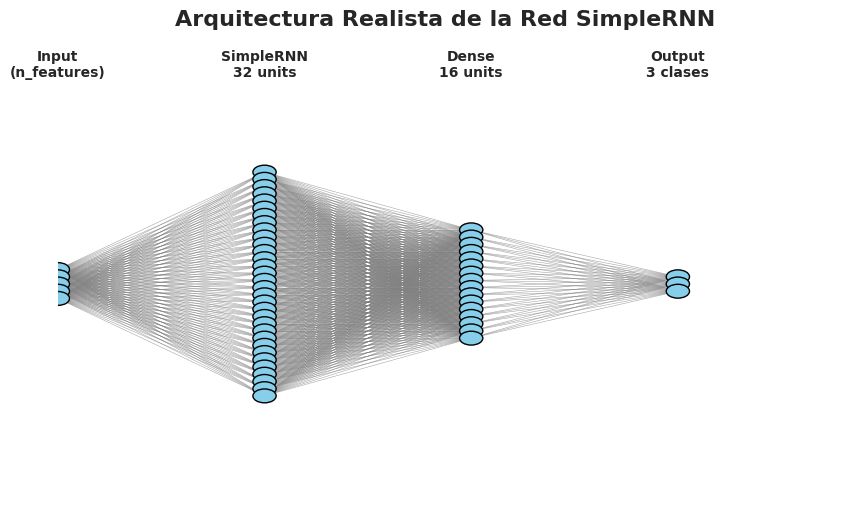

In [ ]:
import matplotlib.pyplot as plt

def draw_neural_net(ax, layer_sizes, layer_names):
    # Espaciado compacto
    max_neurons = max(layer_sizes)
    v_spacing = 0.5 / float(max_neurons)   # vertical
    h_spacing = 0.8 / float(len(layer_sizes) - 1)  # horizontal

    # Dibujar nodos
    for i, layer_size in enumerate(layer_sizes):
        layer_top = v_spacing * (layer_size - 1) / 2.0 + 0.5
        for j in range(layer_size):
            circle = plt.Circle((i * h_spacing, layer_top - j * v_spacing),
                                0.015, color='skyblue', ec='black', zorder=4)  # nodos más pequeños
            ax.add_artist(circle)

    # Dibujar conexiones
    for i, (layer_size_a, layer_size_b) in enumerate(zip(layer_sizes[:-1], layer_sizes[1:])):
        layer_top_a = v_spacing * (layer_size_a - 1) / 2.0 + 0.5
        layer_top_b = v_spacing * (layer_size_b - 1) / 2.0 + 0.5
        for j in range(layer_size_a):
            for k in range(layer_size_b):
                line = plt.Line2D([i * h_spacing, (i + 1) * h_spacing],
                                  [layer_top_a - j * v_spacing, layer_top_b - k * v_spacing],
                                  c='gray', lw=0.4, alpha=0.7)  # líneas más finas y semi-transparente
                ax.add_artist(line)

    # Nombres de capas, centrados sobre cada grupo de nodos
    for i, name in enumerate(layer_names):
        ax.text(i * h_spacing, 0.95, name, fontsize=10, ha='center', weight="bold")

# ====== ARQUITECTURA REALISTA CON TITULOS MEJORADOS ======
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')

# Representación más realista:
layer_sizes = [5, 32, 16, 3]
layer_names = ["Input\n(n_features)", "SimpleRNN\n32 units", "Dense\n16 units", "Output\n3 clases"]

draw_neural_net(ax, layer_sizes, layer_names)
plt.title("Arquitectura Realista de la Red SimpleRNN", fontsize=16, weight="bold", pad=20)
plt.show()

3. COMPILAR EL MODELO

In [ ]:
print("\n" + "="*60)
print("3. COMPILACIÓN DEL MODELO")
print("="*60)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy', #funcion de error
    metrics=['accuracy']
)

print("Modelo compilado con:")
print("- Optimizer: Adam (lr=0.001)")
print("- Loss: categorical_crossentropy")
print("- Metrics: accuracy")


3. COMPILACIÓN DEL MODELO
Modelo compilado con:
- Optimizer: Adam (lr=0.001)
- Loss: categorical_crossentropy
- Metrics: accuracy


 4. ENTRENAMIENTO CON CALLBACK PERSONALIZADO

In [ ]:
print("\n" + "="*60)
print("4. ENTRENAMIENTO DEL MODELO")
print("="*60)

# Callback mejorado para evitar problemas de caracteres
class CustomCallback(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.weights_history = []
        self.losses_history = []

    def on_epoch_end(self, epoch, logs=None):
        # Guardar pesos de la capa SimpleRNN
        rnn_weights = self.model.get_layer('simple_rnn_layer').get_weights()
        self.weights_history.append(rnn_weights)
        self.losses_history.append(logs['loss'])

        # Log limpio cada 10 épocas
        if epoch % 10 == 0:
            print(f"Época {epoch}: pérdida = {logs['loss']:.4f}, precisión = {logs['accuracy']:.4f}")

# Callback para early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Entrenamiento con verbose=0 para evitar problemas de caracteres
custom_callback = CustomCallback()

from sklearn.utils.class_weight import compute_class_weight

# Calcular pesos para balancear aún más
y_train_classes = np.argmax(y_train, axis=1)
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train_classes),
    y=y_train_classes
)
class_weight_dict = dict(enumerate(class_weights))

print(f"\nPesos de clases: {class_weight_dict}")

print("Iniciando entrenamiento...")
history = model.fit(
    X_train, y_train,
    epochs=500,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[custom_callback, early_stopping],
     class_weight=class_weight_dict,
    verbose=0  # Desactivamos el verbose por defecto para evitar caracteres inválidos
)

print("¡Entrenamiento completado!")


4. ENTRENAMIENTO DEL MODELO

Pesos de clases: {0: np.float64(1.0178117048346056), 1: np.float64(0.9644364074743822), 2: np.float64(1.0197578075207139)}
Iniciando entrenamiento...
Época 0: pérdida = 1.5541, precisión = 0.3494
Época 10: pérdida = 0.6018, precisión = 0.7837
Época 20: pérdida = 0.4387, precisión = 0.8512
Época 30: pérdida = 0.3999, precisión = 0.8806
Época 40: pérdida = 0.3405, precisión = 0.9000
Época 50: pérdida = 0.3637, precisión = 0.8950
Época 60: pérdida = 0.3391, precisión = 0.9019
Epoch 70: early stopping
Restoring model weights from the end of the best epoch: 60.
¡Entrenamiento completado!


5. VISUALIZACIONES MEJORADAS


5. GENERANDO VISUALIZACIONES


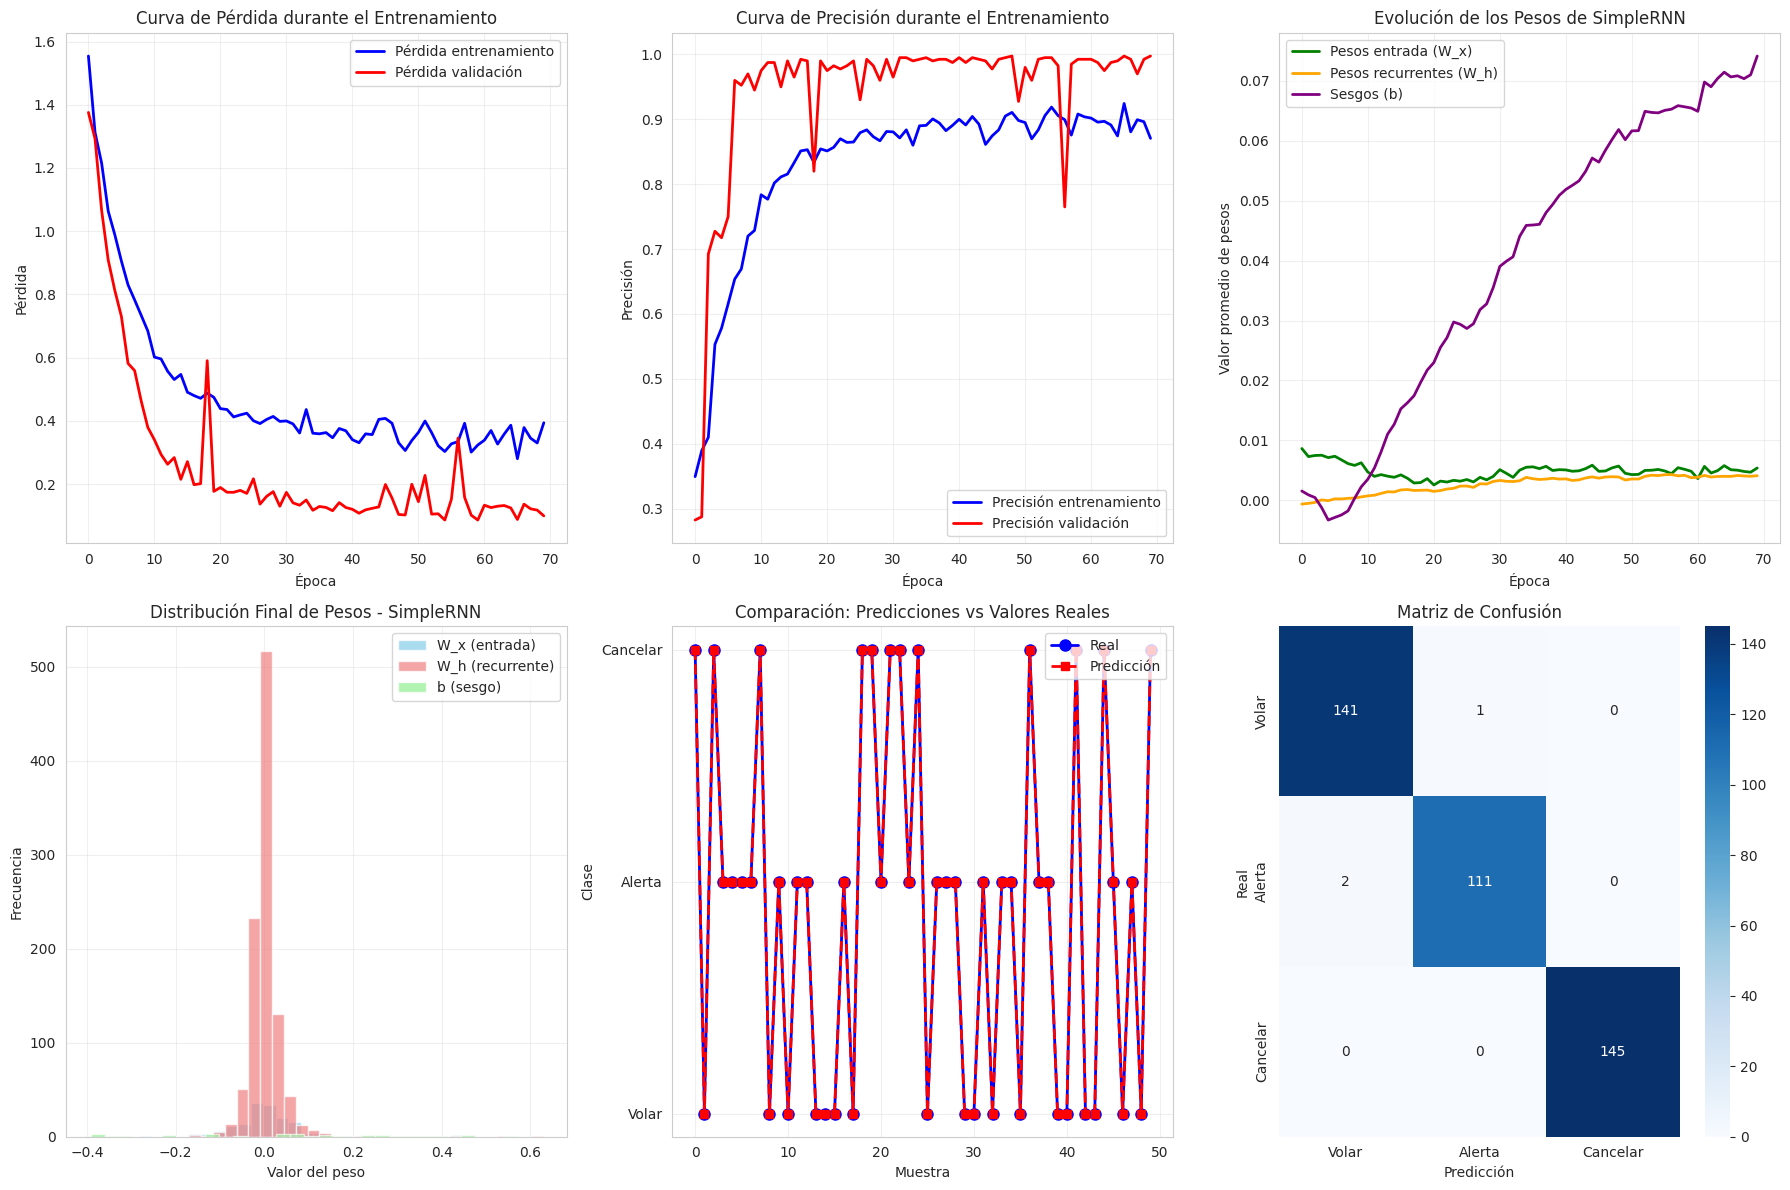

In [ ]:
print("\n" + "="*60)
print("5. GENERANDO VISUALIZACIONES")
print("="*60)

# Crear figura principal
fig = plt.figure(figsize=(18, 12))

# 5.1 Curva de pérdida
plt.subplot(2, 3, 1)
plt.plot(history.history['loss'], label='Pérdida entrenamiento', linewidth=2, color='blue')
plt.plot(history.history['val_loss'], label='Pérdida validación', linewidth=2, color='red')
plt.title('Curva de Pérdida durante el Entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True, alpha=0.3)

# 5.2 Curva de precisión
plt.subplot(2, 3, 2)
plt.plot(history.history['accuracy'], label='Precisión entrenamiento', linewidth=2, color='blue')
plt.plot(history.history['val_accuracy'], label='Precisión validación', linewidth=2, color='red')
plt.title('Curva de Precisión durante el Entrenamiento')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True, alpha=0.3)

# 5.3 Evolución de los pesos de la capa SimpleRNN
plt.subplot(2, 3, 3)
if len(custom_callback.weights_history) > 0:
    # Pesos de entrada (W_x)
    pesos_entrada = np.array([w[0].flatten() for w in custom_callback.weights_history])
    plt.plot(pesos_entrada.mean(axis=1), label='Pesos entrada (W_x)', linewidth=2, color='green')

    # Pesos recurrentes (W_h)
    pesos_recurrentes = np.array([w[1].flatten() for w in custom_callback.weights_history])
    plt.plot(pesos_recurrentes.mean(axis=1), label='Pesos recurrentes (W_h)', linewidth=2, color='orange')

    # Sesgos
    sesgos = np.array([w[2] for w in custom_callback.weights_history])
    plt.plot(sesgos.mean(axis=1), label='Sesgos (b)', linewidth=2, color='purple')

plt.title('Evolución de los Pesos de SimpleRNN')
plt.xlabel('Época')
plt.ylabel('Valor promedio de pesos')
plt.legend()
plt.grid(True, alpha=0.3)

# 5.4 Distribución final de pesos
plt.subplot(2, 3, 4)
pesos_finales = model.get_layer('simple_rnn_layer').get_weights()
nombres_pesos = ['W_x (entrada)', 'W_h (recurrente)', 'b (sesgo)']

colors = ['skyblue', 'lightcoral', 'lightgreen']
for i, (peso, nombre, color) in enumerate(zip(pesos_finales, nombres_pesos, colors)):
    plt.hist(peso.flatten(), alpha=0.7, label=nombre, bins=30, color=color)

plt.title('Distribución Final de Pesos - SimpleRNN')
plt.xlabel('Valor del peso')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, alpha=0.3)

# 5.5 Predicciones vs Reales
plt.subplot(2, 3, 5)
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Muestra de las primeras 50 predicciones
muestra_indices = range(min(50, len(y_pred_classes)))
plt.plot(muestra_indices, y_true_classes[muestra_indices], 'o-',
         label='Real', linewidth=2, markersize=8, color='blue')
plt.plot(muestra_indices, y_pred_classes[muestra_indices], 's--',
         label='Predicción', linewidth=2, markersize=6, color='red')
plt.title('Comparación: Predicciones vs Valores Reales')
plt.xlabel('Muestra')
plt.ylabel('Clase')
plt.yticks([0, 1, 2], ['Volar', 'Alerta', 'Cancelar'])
plt.legend()
plt.grid(True, alpha=0.3)

# 5.6 Matriz de confusión
plt.subplot(2, 3, 6)
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_true_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Volar', 'Alerta', 'Cancelar'],
            yticklabels=['Volar', 'Alerta', 'Cancelar'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')

plt.tight_layout()
plt.show()

6. ANÁLISIS DE PESOS Y PREDICCIONES

In [ ]:
print("\n" + "="*60)
print("6. ANÁLISIS DETALLADO DE PESOS Y PREDICCIONES")
print("="*60)

# Obtener pesos finales
rnn_layer = model.get_layer('simple_rnn_layer')
pesos_rnn = rnn_layer.get_weights()

W_x = pesos_rnn[0]  # Pesos de entrada (5 features → 50 unidades)
W_h = pesos_rnn[1]  # Pesos recurrentes (50 → 50)
b = pesos_rnn[2]    # Sesgos

print(f"\nForma de los pesos:")
print(f"W_x (entrada): {W_x.shape}")      # (5, 50)
print(f"W_h (recurrente): {W_h.shape}")   # (50, 50)
print(f"b (sesgo): {b.shape}")            # (50,)

# Análisis de importancia de características
importancia_caracteristicas = np.mean(np.abs(W_x), axis=1)
caracteristicas = ['Temperatura', 'Humedad', 'Viento', 'Lluvia', 'Presión']

print(f"\nImportancia relativa de características (basada en pesos absolutos):")
for carac, imp in zip(caracteristicas, importancia_caracteristicas):
    print(f"  {carac}: {imp:.4f}")

# Mostrar reporte de clasificación
print(f"\nReporte de Clasificación:")
print(classification_report(y_true_classes, y_pred_classes,
                          target_names=['Volar', 'Alerta', 'Cancelar']))


6. ANÁLISIS DETALLADO DE PESOS Y PREDICCIONES

Forma de los pesos:
W_x (entrada): (5, 32)
W_h (recurrente): (32, 32)
b (sesgo): (32,)

Importancia relativa de características (basada en pesos absolutos):
  Temperatura: 0.0429
  Humedad: 0.0619
  Viento: 0.0874
  Lluvia: 0.0742
  Presión: 0.0172

Reporte de Clasificación:
              precision    recall  f1-score   support

       Volar       0.99      0.99      0.99       142
      Alerta       0.99      0.98      0.99       113
    Cancelar       1.00      1.00      1.00       145

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



7. EJEMPLO DE PREDICCIÓN CON NUEVOS DATOS

In [ ]:
print("\n" + "="*60)
print("7. EJEMPLO DE PREDICCIÓN PARA DRONES")
print("="*60)

# Generar datos de ejemplo para predicción
datos_ejemplo = np.array([[
    [28.0, 65.0, 12.0, 0.1, 1012.0],  # Día 1
    [29.0, 62.0, 15.0, 0.0, 1011.0],  # Día 2
    [30.0, 60.0, 18.0, 0.0, 1010.0],  # Día 3
    [31.0, 58.0, 20.0, 0.0, 1009.0],  # Día 4
    [32.0, 55.0, 22.0, 0.0, 1008.0],  # Día 5
    [33.0, 53.0, 25.0, 0.0, 1007.0],  # Día 6
    [32.0, 55.0, 28.0, 0.2, 1008.0],  # Día 7
    [31.0, 58.0, 30.0, 0.5, 1009.0],  # Día 8
    [30.0, 62.0, 32.0, 1.0, 1010.0],  # Día 9
    [29.0, 65.0, 35.0, 2.0, 1011.0],  # Día 10 (actual)
]])

prediccion = model.predict(datos_ejemplo, verbose=0)
clase_predicha = np.argmax(prediccion, axis=1)[0]
probabilidades = prediccion[0]

clases = {0: "VOLAR ✓", 1: "ALERTA ⚠", 2: "CANCELAR ✗"}

print(f"\nPredicción para condiciones climáticas:")
print(f"Probabilidad VOLAR: {probabilidades[0]:.2%}")
print(f"Probabilidad ALERTA: {probabilidades[1]:.2%}")
print(f"Probabilidad CANCELAR: {probabilidades[2]:.2%}")
print(f"\nDECISIÓN FINAL: {clases[clase_predicha]}")


7. EJEMPLO DE PREDICCIÓN PARA DRONES

Predicción para condiciones climáticas:
Probabilidad VOLAR: 0.24%
Probabilidad ALERTA: 84.96%
Probabilidad CANCELAR: 14.80%

DECISIÓN FINAL: ALERTA ⚠


8. EXPLICACIÓN

APLICACIÓN EN DRONES:
- Analiza secuencias de datos climáticos (10 días)
- Aprende patrones temporales en el clima
- Predice si es seguro volar basado en tendencias

VENTAJAS:
- Captura dependencias temporales
- Modelado de secuencias
- Memoria a corto plazo

LIMITACIONES:
- Problema de gradientes vanishing/exploding
- Memoria limitada a corto plazo

9. EVALUACIÓN FINAL

In [ ]:
print("\n" + "="*60)
print("EVALUACIÓN FINAL DEL MODELO")
print("="*60)
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Precisión en test: {test_accuracy:.2%}")
print(f"Pérdida en test: {test_loss:.4f}")

# Predicciones en el conjunto de test
y_pred_test = model.predict(X_test, verbose=0)
y_pred_classes_test = np.argmax(y_pred_test, axis=1)

# Calcular precisión por clase
from sklearn.metrics import accuracy_score
clase_accuracy = []
for clase in range(3):
    mask = y_true_classes == clase
    if np.sum(mask) > 0:
        acc = accuracy_score(y_true_classes[mask], y_pred_classes_test[mask])
        clase_accuracy.append(acc)
    else:
        clase_accuracy.append(0)

nombres_clases = ['Volar', 'Alerta', 'Cancelar']
print(f"\nPrecisión por clase:")
for nombre, acc in zip(nombres_clases, clase_accuracy):
    print(f"  {nombre}: {acc:.2%}")


EVALUACIÓN FINAL DEL MODELO
Precisión en test: 99.25%
Pérdida en test: 0.0865

Precisión por clase:
  Volar: 99.30%
  Alerta: 98.23%
  Cancelar: 100.00%
